In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.decomposition import PCA

In [2]:
debt_complaints_2021 = pd.read_csv("debt-complaints-2021.csv")
debt_complaints_2022 = pd.read_csv("debt-complaints-2022.csv")
debt_complaints_2023 = pd.read_csv("debt-complaints-2023.csv")
debt_complaints_2024 = pd.read_csv("debt-complaints-2024.csv")
debt_complaints_2025 = pd.read_csv("2025_complaints_combined.csv")

In [3]:
top10_pct_2021 = (debt_complaints_2021["Sub-product"].value_counts(normalize=True).head(10) * 100).round(2)
top10_pct_2022 = (debt_complaints_2022["Sub-product"].value_counts(normalize=True).head(10) * 100).round(2)
top10_pct_2023 = (debt_complaints_2023["Sub-product"].value_counts(normalize=True).head(10) * 100).round(2)
top10_pct_2024 = (debt_complaints_2024["Sub-product"].value_counts(normalize=True).head(10) * 100).round(2)
top10_pct_2025 = (debt_complaints_2025["Sub-product"].value_counts(normalize=True).head(10) * 100).round(2)

In [4]:
shares = pd.concat([top10_pct_2021, top10_pct_2022, top10_pct_2023, top10_pct_2024, top10_pct_2025], axis=1)
shares.columns = ["2021", "2022", "2023", "2024", "2025"]
shares = shares.fillna(0)



In [5]:
# Changes between years, in percentage points
shares["Change 2021 ->2022"] = shares["2022"] - shares["2021"]
shares["Change 2022 ->2023"] = shares["2023"] - shares["2022"]
shares["Change 2023 ->2024"] = shares["2024"] - shares["2023"]
shares["Change 2024 ->2025"] = shares["2025"] - shares["2024"]
shares["Change 2021 ->2025"] = shares["2025"] - shares["2021"]

In [6]:
top10 = shares.sort_values("2025", ascending=False).head(10)

In [7]:
# Sort by the overall change, biggest gain first
shares = shares.sort_values("Change 2021 ->2025", ascending=False).round(2)
print(shares)

                            2021   2022   2023   2024   2025  \
Sub-product                                                    
Rental debt                 0.00   0.00   3.60   0.00   8.94   
Telecommunications debt     0.00   0.00   3.79   0.00   8.73   
Other debt                 31.98  35.72  33.51  37.43  34.90   
Auto debt                   6.20   6.35   6.60   6.92   6.41   
Federal student loan debt   0.93   0.82   0.86   0.78   0.76   
Private student loan debt   1.00   1.03   0.91   0.82   0.72   
Payday loan debt            3.09   2.78   2.88   2.81   2.14   
Mortgage debt               1.87   2.10   1.68   1.10   0.56   
Credit card debt           35.46  31.14  31.30  39.49  30.00   
Medical debt               19.47  20.07  14.87  10.65   6.87   

                           Change 2021 ->2022  Change 2022 ->2023  \
Sub-product                                                         
Rental debt                              0.00                3.60   
Telecommunications debt 

In [8]:
# years = ["2021", "2022", "2023", "2024", "2025"]
# colors = ["#9ecae1", "#4292c6", "#08519c"]   # light -> dark = older -> newer
# y = np.arange(len(top10))
# h = 0.27

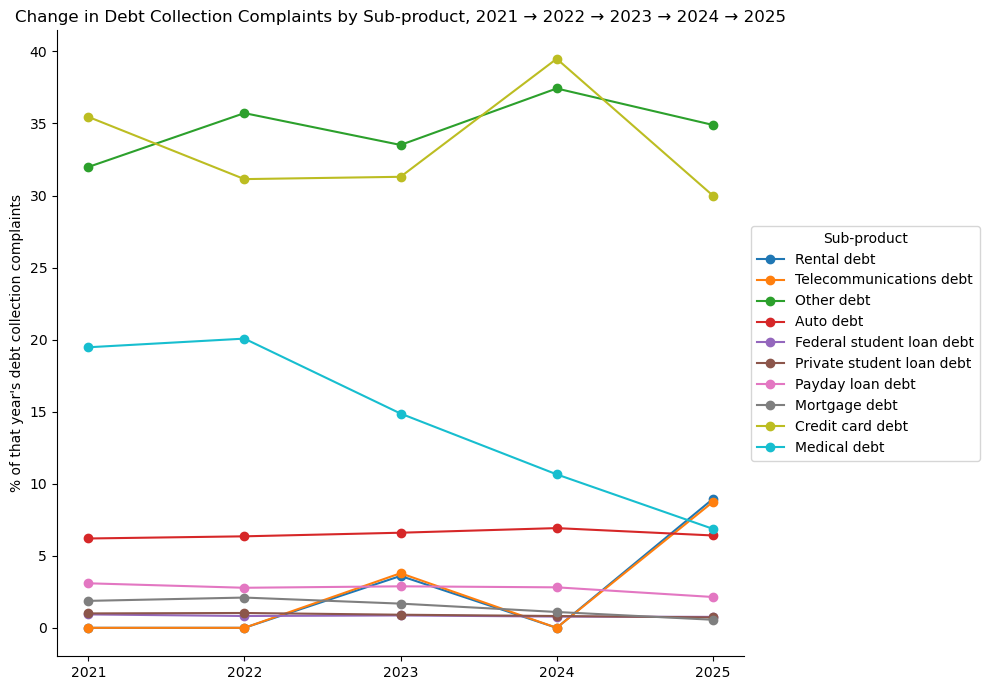

In [9]:
# Line chart: one line per sub-product across 2021 -> 2023 -> 2025
years = ["2021", "2022", "2023", "2024", "2025"]
fig, ax = plt.subplots(figsize=(10, 7))

for subproduct, row in shares.iterrows():
    ax.plot(years, row[years], marker="o", label=subproduct)

ax.set_ylabel("% of that year's debt collection complaints")
ax.set_title("Change in Debt Collection Complaints by Sub-product, 2021 → 2022 → 2023 → 2024 → 2025")
ax.legend(title="Sub-product", loc="center left", bbox_to_anchor=(1, 0.5))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [10]:
rental_2025 = debt_complaints_2025[debt_complaints_2025["Sub-product"] == "Rental debt"]
print(len(rental_2025), "rental debt complaints in 2025")
rental_2025.head(100)

11513 rental debt complaints in 2025


,Date received,Product,Sub-product,Issue,Sub-issue,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
3,2025-12-31T22:53:36.000Z,Debt collection,Rental debt,Attempts to collect debt not owed,Debt is not yours,NaN,"Sequium Asset Solutions, LLC",TX,75074,NaN,Web,2026-01-01T00:05:02.000Z,Closed with non-monetary relief,Yes,18398314
31,2025-12-31T20:52:54.000Z,Debt collection,Rental debt,Written notification about debt,Didn't receive enough information to verify debt,NaN,"ResidentCollect, Inc.",MI,48348,NaN,Web,2025-12-31T21:10:32.000Z,Closed with explanation,Yes,18396904
37,2025-12-31T20:38:00.000Z,Debt collection,Rental debt,Took or threatened to take negative or legal a...,Threatened or suggested your credit would be d...,NaN,"National Credit Systems,Inc.",VA,22209,NaN,Web,2025-12-31T20:51:08.000Z,Closed with explanation,Yes,18396700
42,2025-12-31T20:11:23.000Z,Debt collection,Rental debt,False statements or representation,Attempted to collect wrong amount,Company has responded to the consumer and the ...,"FAIR COLLECTIONS & OUTSOURCING, INC.",NC,273XX,Servicemember,Web,2025-12-31T20:26:19.000Z,Closed with explanation,Yes,18396440
43,2025-12-31T20:06:39.000Z,Debt collection,Rental debt,Attempts to collect debt not owed,Debt is not yours,NaN,"Sequium Asset Solutions, LLC",NC,28560,NaN,Web,2025-12-31T20:29:14.000Z,Closed with non-monetary relief,Yes,18396458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
934,2025-12-29T07:14:57.000Z,Debt collection,Rental debt,Written notification about debt,Didn't receive enough information to verify debt,NaN,"RentDebt Automated Collections, LLC",NC,27890,NaN,Web,2025-12-29T07:30:11.000Z,Closed with explanation,Yes,18335858
940,2025-12-29T06:28:04.000Z,Debt collection,Rental debt,False statements or representation,Attempted to collect wrong amount,NaN,"HW Holding, Inc",OH,44202,NaN,Web,2025-12-29T06:41:20.000Z,Closed with explanation,Yes,18335412
949,2025-12-29T05:03:41.000Z,Debt collection,Rental debt,Attempts to collect debt not owed,Debt is not yours,NaN,"Collection Bureau of Fort Walton Beach, Inc",AL,36203,NaN,Web,2025-12-29T05:15:46.000Z,Closed with explanation,Yes,18334751
959,2025-12-29T03:31:00.000Z,Debt collection,Rental debt,Took or threatened to take negative or legal a...,Threatened or suggested your credit would be d...,NaN,"Aldous & Associates, PLLC",WA,98106,NaN,Web,2025-12-29T03:40:49.000Z,Closed with explanation,Yes,18333894


In [11]:
tele_2025 = debt_complaints_2025[debt_complaints_2025["Sub-product"] == "Telecommunications debt"]
print(len(tele_2025), "Telecommunications debt complaints in 2025")
tele_2025.head(100)

11240 Telecommunications debt complaints in 2025


,Date received,Product,Sub-product,Issue,Sub-issue,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
26,2025-12-31T20:58:52.000Z,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,Company believes it acted appropriately as aut...,"MRS BPO, LLC",NY,14843,Older American,Web,2025-12-31T21:30:49.000Z,Closed with non-monetary relief,Yes,18397089
52,2025-12-31T19:44:06.000Z,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt was result of identity theft,NaN,Source Receivables Management LLC,PA,19605,NaN,Web,2025-12-31T19:46:13.000Z,Closed with explanation,Yes,18395948
53,2025-12-31T19:40:18.000Z,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,"Kriya Capital, LLC",CA,95337,NaN,Web,2025-12-31T20:11:48.000Z,Closed with non-monetary relief,Yes,18396264
60,2025-12-31T19:14:10.000Z,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,"Kriya Capital, LLC",OR,97211,NaN,Web,2025-12-31T19:56:01.000Z,Closed with non-monetary relief,Yes,18396066
61,2025-12-31T19:12:40.000Z,Debt collection,Telecommunications debt,False statements or representation,Attempted to collect wrong amount,NaN,TrueAccord Corp.,CO,80649,NaN,Web,2025-12-31T19:38:15.000Z,Closed with explanation,Yes,18395866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1151,2025-12-28T00:28:50.000Z,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,Company believes it acted appropriately as aut...,"Harris & Harris, Ltd.",IL,60085,NaN,Web,2025-12-28T00:45:01.000Z,Closed with non-monetary relief,Yes,18323280
1152,2025-12-28T00:22:50.000Z,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,Company has responded to the consumer and the ...,"I.C. System, Inc.",LA,713XX,NaN,Web,2025-12-28T00:45:07.000Z,Closed with explanation,Yes,18323282
1157,2025-12-27T23:51:45.000Z,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt was paid,NaN,"Kriya Capital, LLC",NV,89148,Servicemember,Web,2025-12-28T00:04:44.000Z,Closed with non-monetary relief,Yes,18322972
1160,2025-12-27T23:14:54.000Z,Debt collection,Telecommunications debt,Took or threatened to take negative or legal a...,Threatened or suggested your credit would be d...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",FL,33069,NaN,Web,2025-12-27T23:21:40.000Z,Closed with non-monetary relief,Yes,18322667


In [12]:
tele_not_yours_2025 = tele_2025[tele_2025["Sub-issue"] == "Debt is not yours"]

print(len(tele_not_yours_2025), "telecom complaints where the debt is not yours")
print(round(len(tele_not_yours_2025) / len(tele_2025) * 100, 1), "% of telecom debt complaints")

3602 telecom complaints where the debt is not yours
32.0 % of telecom debt complaints


In [13]:
company_counts = tele_not_yours_2025["Company"].value_counts()
top10_companies = pd.DataFrame({
    "Complaints": company_counts.head(10),
    "% of total": (company_counts.head(10) / len(tele_not_yours_2025) * 100).round(1),
})
print(top10_companies)

print("\nTotal companies:", company_counts.size)
print("Top 5 share", round(company_counts.head(5).sum()/ len(tele_not_yours_2025) * 100, 1), "%")

                                   Complaints  % of total
Company                                                  
CL Holdings LLC                           488        13.5
Kriya Capital, LLC                        463        12.9
I.C. System, Inc.                         273         7.6
TRANSWORLD SYSTEMS INC                    215         6.0
Radius Global Solutions LLC               167         4.6
Harris & Harris, Ltd.                     142         3.9
Southwest Credit Systems, L.P.            141         3.9
Source Receivables Management LLC         140         3.9
SUNRISE CREDIT SERVICES, INC              132         3.7
Amsher Collection Services, Inc.          116         3.2

Total companies: 142
Top 5 share 44.6 %


In [14]:
top3 = company_counts.head(3)
top3_n = top3.sum()
subissue_total = len(tele_not_yours_2025)
telecom_total = len(tele_2025)

sub_share = top3_n / subissue_total * 100
all_share = top3_n / telecom_total * 100


In [15]:
print("Top 3 companies:")
print(top3)
print(f"\nTop 3 total: {top3_n:,} complaints")
print(f"Top 3 share of 'debt is not yours': {sub_share:.1f}%")
print(f"Top 3 share of ALL telecom complaints: {all_share:.1f}%")

Top 3 companies:
Company
CL Holdings LLC       488
Kriya Capital, LLC    463
I.C. System, Inc.     273
Name: count, dtype: int64

Top 3 total: 1,224 complaints
Top 3 share of 'debt is not yours': 34.0%
Top 3 share of ALL telecom complaints: 10.9%


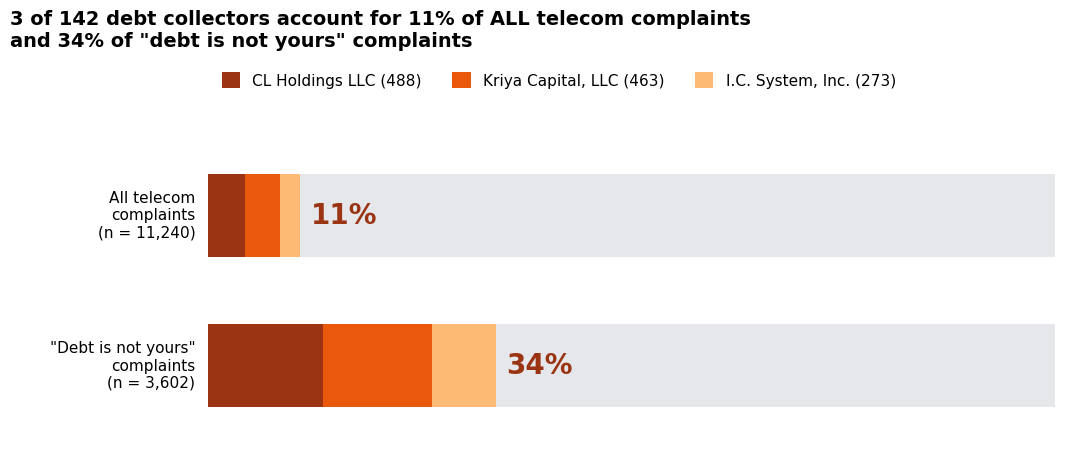

In [16]:
colors = ["#9a3412", "#ea580c", "#fdba74"]
grey = "#e5e7eb"
rows = [("All telecom\ncomplaints", telecom_total),
        ('"Debt is not yours"\ncomplaints', subissue_total)]

fig, ax = plt.subplots(figsize=(11, 4.8))
for y, (label, total) in zip([1, 0], rows):
    ax.barh(y, 100, color=grey, height=0.55)
    left = 0
    for (name, n), c in zip(top3.items(), colors):
        w = n / total * 100
        ax.barh(y, w, left=left, color=c, height=0.55,
                label=f"{name} ({n:,})" if y == 1 else None)
        left += w
    ax.text(left + 1.2, y, f"{left:.0f}%", va="center",
            fontsize=20, fontweight="bold", color="#9a3412")
    ax.text(-1.5, y, f"{label}\n(n = {total:,})", va="center", ha="right", fontsize=11)

ax.set_xlim(0, 100)
ax.set_ylim(-0.6, 1.6)
ax.axis("off")
ax.legend(loc="upper left", bbox_to_anchor=(0, 1.2), ncol=3, frameon=False,
          fontsize=11, handlelength=1.2, handleheight=1.2)

fig.suptitle(f"3 of {company_counts.size} debt collectors account for {all_share:.0f}% "
             f"of ALL telecom complaints\nand {sub_share:.0f}% of \"debt is not yours\" complaints",
             x=0.02, ha="left", fontsize=14, fontweight="bold")



plt.subplots_adjust(left=0.2, right=0.97, top=0.74, bottom=0.05)
plt.savefig("top3_complaints.png", dpi=200, facecolor="white")
plt.show()

In [17]:
years = [debt_complaints_2021, debt_complaints_2022, debt_complaints_2023,
         debt_complaints_2024, debt_complaints_2025]
df = pd.concat([d.assign(year=str(y)) for y, d in zip(range(2021, 2026), years)])
df = df.drop_duplicates("Complaint ID")
df = df[df["Company response to consumer"].str.startswith("Closed with", na=False)].copy()
df["y"] = df["Company response to consumer"].str.contains("relief").astype(int)
df["month"] = pd.to_datetime(df["Date received"]).dt.month.astype(str)

# Only features known when the complaint is filed (no leakage from the company's response)
CAT = ["Company", "Sub-product", "Issue", "Sub-issue", "State",
       "Submitted via", "Tags", "year", "month"]
df[CAT] = df[CAT].fillna("Missing").astype(str)
print(f"{len(df):,} complaints, relief rate {df.y.mean():.1%}")

train, test = train_test_split(df, test_size=0.2, stratify=df.y, random_state=42)

ohe = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20)
Xtr = ohe.fit_transform(train[CAT])
Xte = ohe.transform(test[CAT])
print(f"{Xtr.shape[1]:,} one-hot features")


343,966 complaints, relief rate 20.8%
966 one-hot features


In [18]:
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu",
                    alpha=1e-4, batch_size=1024, learning_rate_init=1e-3,
                    max_iter=50, early_stopping=True, validation_fraction=0.1,
                    n_iter_no_change=3, random_state=42, verbose=True)
mlp.fit(Xtr, train.y)
p_mlp = mlp.predict_proba(Xte)[:, 1]

Iteration 1, loss = 0.35661994
Validation score: 0.866415
Iteration 2, loss = 0.27207622
Validation score: 0.874264
Iteration 3, loss = 0.25967149
Validation score: 0.872047
Iteration 4, loss = 0.25364235
Validation score: 0.875500
Iteration 5, loss = 0.24864942
Validation score: 0.874155
Iteration 6, loss = 0.24497149
Validation score: 0.873283
Iteration 7, loss = 0.24224642
Validation score: 0.874082
Iteration 8, loss = 0.23948638
Validation score: 0.872265
Validation score did not improve more than tol=0.000100 for 3 consecutive epochs. Stopping.


In [19]:
lr = LogisticRegression(max_iter=2000).fit(Xtr, train.y)
p_lr = lr.predict_proba(Xte)[:, 1]

mlp_auc, lr_auc = roc_auc_score(test.y, p_mlp), roc_auc_score(test.y, p_lr)
print(f"\nTest AUC  |  Neural net: {mlp_auc:.3f}   Logistic regression: {lr_auc:.3f}")


Test AUC  |  Neural net: 0.929   Logistic regression: 0.901


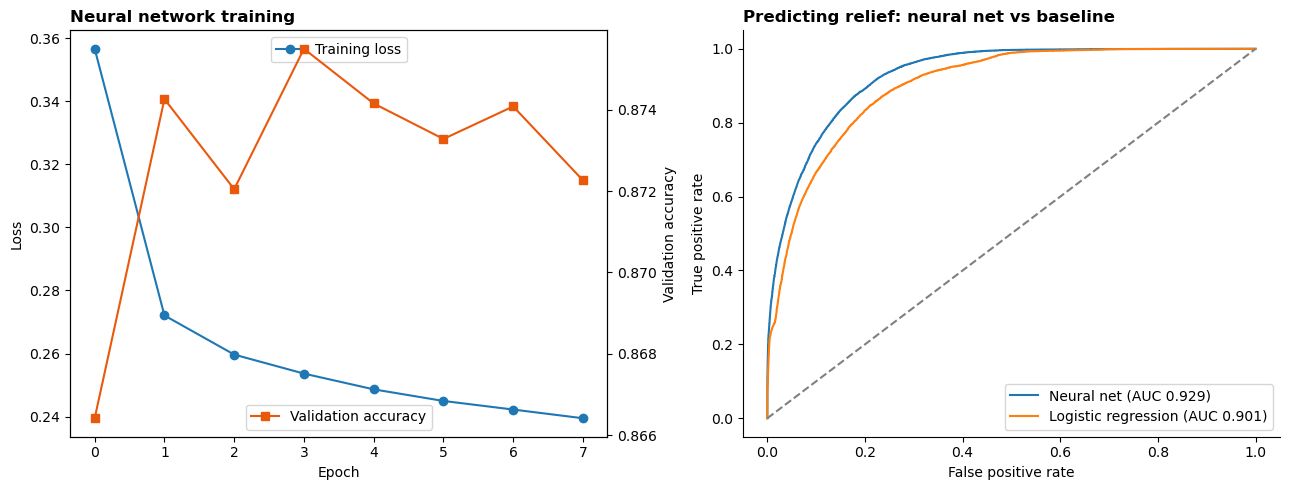

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(mlp.loss_curve_, marker="o", label="Training loss")
ax1b = ax1.twinx()
ax1b.plot(mlp.validation_scores_, marker="s", color="#ea580c", label="Validation accuracy")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1b.set_ylabel("Validation accuracy")
ax1.set_title("Neural network training", loc="left", fontweight="bold")
ax1.legend(loc="upper center"); ax1b.legend(loc="lower center")

for name, p, auc in [("Neural net", p_mlp, mlp_auc), ("Logistic regression", p_lr, lr_auc)]:
    fpr, tpr, _ = roc_curve(test.y, p)
    ax2.plot(fpr, tpr, label=f"{name} (AUC {auc:.3f})")
ax2.plot([0, 1], [0, 1], "--", color="gray")
ax2.set_xlabel("False positive rate"); ax2.set_ylabel("True positive rate")
ax2.set_title("Predicting relief: neural net vs baseline", loc="left", fontweight="bold")
ax2.legend(); ax2.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("relief_model_comparison.png", dpi=200, facecolor="white")
plt.show()

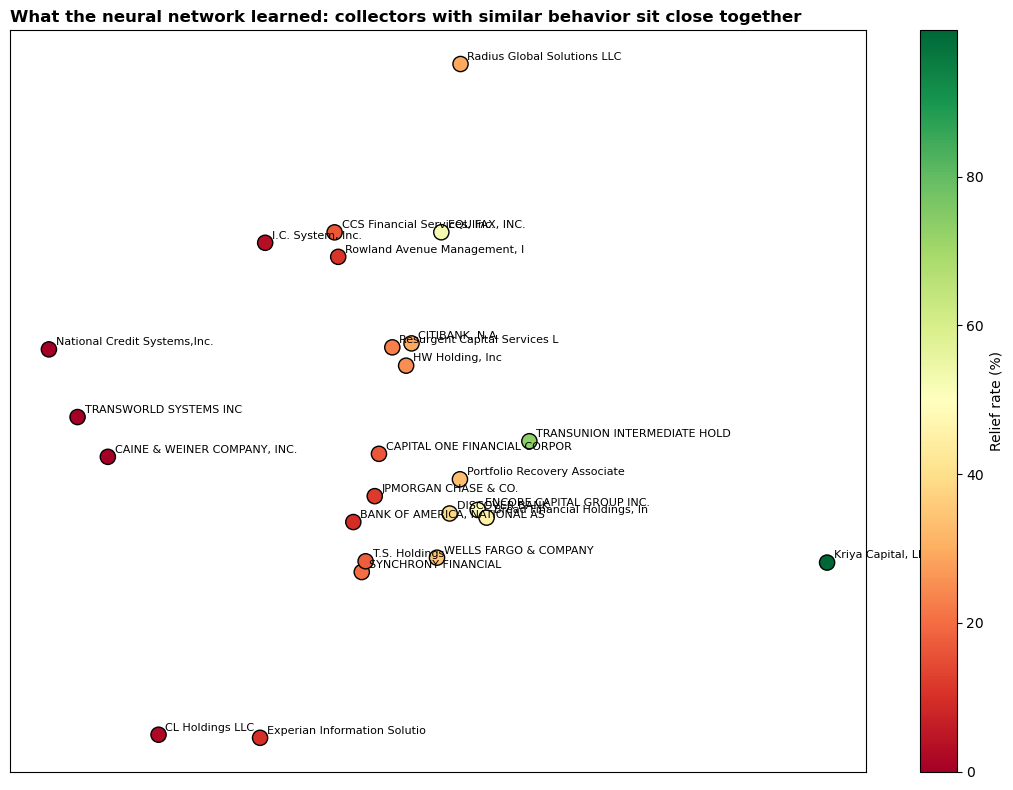

In [21]:
names = ohe.get_feature_names_out(CAT)
first_layer = mlp.coefs_[0]                        # shape: (n_features, 128)
top = train["Company"].value_counts().head(25).index
rows = [np.where(names == f"Company_{c}")[0] for c in top]
keep = [(c, r[0]) for c, r in zip(top, rows) if len(r)]
vecs = first_layer[[r for _, r in keep]]
xy = PCA(n_components=2).fit_transform(vecs)
rate = train.groupby("Company")["y"].mean()[[c for c, _ in keep]] * 100

fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(xy[:, 0], xy[:, 1], c=rate, cmap="RdYlGn", s=120, edgecolor="black")
for (x, y_), (name, _) in zip(xy, keep):
    ax.annotate(name[:28], (x, y_), fontsize=8, xytext=(5, 3), textcoords="offset points")
plt.colorbar(sc, label="Relief rate (%)")
ax.set_title("What the neural network learned: collectors with similar behavior sit close together",
             loc="left", fontweight="bold")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("collector_embeddings.png", dpi=200, facecolor="white")
plt.show()